# Part 2

In [2]:
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import random

In [3]:
mnist_train = datasets.MNIST(
    root="./data",
    train=True,
    transform=transforms.ToTensor(),
    download=True
)
mnist_test = datasets.MNIST(
    root="./data",
    train=False,
    transform=transforms.ToTensor(),
    download=True
)
print("MNIST downloaded successfully!")

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.44MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 92.7kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.21MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.81MB/s]

MNIST downloaded successfully!


In [4]:
train_dataset = mnist_train
test_dataset = mnist_test

print(f"Train size: {len(train_dataset)}")
print(f"Test size: {len(test_dataset)}")
# Class distribution for training dataset
labels = [int(y) for (_, y) in train_dataset]
counts = Counter(labels)
labels_sorted = sorted(counts.items())
xs = [k for k, v in labels_sorted]
ys = [v for k, v in labels_sorted]


Train size: 60000
Test size: 10000


In [5]:
seed = 4786
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

batch_size = 128
transform = transforms.ToTensor()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Using device: cpu


## Shifted MNIST test set (translating every image 4 pixels to the right)

In [6]:
class ShiftRight4Pixels:
    def __call__(self, img):
        shifted_img = torch.zeros_like(img)

        # Shift the image 4 pixels to the right
        # Copy original image data from column 0 up to (W-4) to shifted_img from column 4 up to W
        # Assuming image shape is (C, H, W)
        # In PyTorch, indexing for width (W) is typically the last dimension for (C, H, W) or (H, W)
        # For MNIST, it's (1, 28, 28)

        # Ensure the image has at least 4 pixels width to shift
        if img.shape[-1] > 4:
            shifted_img[..., :, 4:] = img[..., :, :-4]

        return shifted_img

In [7]:
shifted_transform = transforms.Compose([
    transforms.ToTensor(),
    ShiftRight4Pixels()
])

mnist_train_shifted = datasets.MNIST(
    root="./data",
    train=True,
    transform=shifted_transform,
    download=True
)
mnist_test_shifted = datasets.MNIST(
    root="./data",
    train=False,
    transform=shifted_transform,
    download=True
)

train_loader_shifted = DataLoader(mnist_train_shifted, batch_size=batch_size, shuffle=True)
test_loader_shifted = DataLoader(mnist_test_shifted, batch_size=batch_size, shuffle=False)

## CNN model

In [8]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # First convolutional layer
        # Input: 1 channel (MNIST images are grayscale)
        # Output: 32 channels
        # Kernel size: 3x3
        # Padding: 'same' to maintain spatial dimensions
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding='same')
        self.leaky1 = nn.LeakyReLU(negative_slope=0.01)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces 28x28 to 14x14

        # Second convolutional layer
        # Input: 32 channels
        # Output: 64 channels
        # Kernel size: 3x3
        # Padding: 'same'
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding='same')
        self.leaky2 = nn.LeakyReLU(negative_slope=0.01)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Reduces 14x14 to 7x7

        # Fully connected layers
        # The output from pool2 will be 64 channels * 7 * 7 = 3136 features
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.leaky3 = nn.LeakyReLU(negative_slope=0.01)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x, return_proba=False):
        # x: batch x 1 x 28 x 28
        x = self.pool1(self.leaky1(self.conv1(x))) # Output: batch x 32 x 14 x 14
        x = self.pool2(self.leaky2(self.conv2(x))) # Output: batch x 64 x 7 x 7

        # Flatten the output for the fully connected layers
        x = x.view(x.size(0), -1) # Output: batch x (64 * 7 * 7)

        x = self.leaky3(self.fc1(x)) # Output: batch x 128
        logits = self.fc2(x) # Output: batch x num_classes

        if return_proba:
            return torch.softmax(logits, dim=1)
        return logits

print("SimpleCNN class defined.")

SimpleCNN class defined.


## FCNN model

In [9]:
class SimpleFCNN(nn.Module):
    def __init__(self, input_dim=28*28, h1=256, h2=128, h3=64, num_classes=10):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, h3)
        self.fc4 = nn.Linear(h3, num_classes)
        self.leaky = nn.LeakyReLU(negative_slope=0.01)

    def forward(self, x, return_proba=False):
        # x: batch x 1 x 28 x 28
        x = x.view(x.size(0), -1)  # flatten
        a1 = self.leaky(self.fc1(x))
        a2 = self.leaky(self.fc2(a1))
        a3 = self.leaky(self.fc3(a2))
        logits = self.fc4(a3)
        if return_proba:
            return torch.softmax(logits, dim=1)
        return logits

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for imgs, targets in loader:
        imgs = imgs.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    return running_loss / len(loader.dataset)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, targets in loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            outputs = model(imgs)
            _, preds = torch.max(outputs, dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    return correct / total

epochs = 5
model = SimpleFCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

losses_normal = []
losses_scrambled = []

fcnn_accuracies_normal_epochs = []
fcnn_accuracies_shifted_epochs = []

for ep in range(1, epochs+1):
    loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    losses_normal.append(loss)

    acc_normal = evaluate(model, test_loader, device)
    fcnn_accuracies_normal_epochs.append(acc_normal)

    acc_shifted = evaluate(model, test_loader_shifted, device)
    fcnn_accuracies_shifted_epochs.append(acc_shifted)

    print(f'[Normal MNIST] Epoch {ep}/{epochs}  Loss: {loss:.4f}  Test Acc Normal: {acc_normal*100:.2f}%  Test Acc Shifted: {acc_shifted*100:.2f}%')

FCNN_acc_shifted= evaluate(model, test_loader_shifted, device)
FCNN_acc_normal = evaluate(model,test_loader,device)
print('Final test accuracy on Normal MNIST: {:.2f}%'.format(FCNN_acc_normal*100))
print('Final test accuracy on Shifted MNIST: {:.2f}%'.format(FCNN_acc_shifted*100))


[Normal MNIST] Epoch 1/5  Loss: 0.3733  Test Acc Normal: 94.48%  Test Acc Shifted: 23.87%
[Normal MNIST] Epoch 2/5  Loss: 0.1353  Test Acc Normal: 96.37%  Test Acc Shifted: 34.44%
[Normal MNIST] Epoch 3/5  Loss: 0.0885  Test Acc Normal: 97.20%  Test Acc Shifted: 33.77%
[Normal MNIST] Epoch 4/5  Loss: 0.0649  Test Acc Normal: 97.32%  Test Acc Shifted: 36.66%
[Normal MNIST] Epoch 5/5  Loss: 0.0479  Test Acc Normal: 97.85%  Test Acc Shifted: 40.94%
Final test accuracy on Normal MNIST: 97.85%
Final test accuracy on Shifted MNIST: 40.94%


## CNN Accuracy

In [10]:
cnn_model = SimpleCNN().to(device)
c_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
c_criterion = nn.CrossEntropyLoss()

epochs = 5

losses_shifted = []

cnn_accuracies_normal_epochs = []
cnn_accuracies_shifted_epochs = []

print("\n--- Training SimpleCNN on Shifted MNIST ---")
for ep in range(1, epochs + 1):
    loss = train_one_epoch(cnn_model, train_loader, c_optimizer, c_criterion, device)
    losses_shifted.append(loss)

    acc_normal = evaluate(cnn_model, test_loader, device)
    cnn_accuracies_normal_epochs.append(acc_normal)

    acc_shifted = evaluate(cnn_model, test_loader_shifted, device)
    cnn_accuracies_shifted_epochs.append(acc_shifted)

    print(f'[Shifted MNIST] Epoch {ep}/{epochs}  Loss: {loss:.4f}  Test Acc Normal: {acc_normal*100:.2f}%  Test Acc Shifted: {acc_shifted*100:.2f}%')

CNN_acc_shifted = evaluate(cnn_model, test_loader_shifted, device)
CNN_acc_normal = evaluate(cnn_model, test_loader, device)
print('Final test accuracy on Normal MNIST: {:.2f}%'.format(CNN_acc_normal*100))
print('Final test accuracy on Shifted MNIST: {:.2f}%'.format(CNN_acc_shifted*100))



--- Training SimpleCNN on Shifted MNIST ---
[Shifted MNIST] Epoch 1/5  Loss: 0.2214  Test Acc Normal: 98.08%  Test Acc Shifted: 59.36%
[Shifted MNIST] Epoch 2/5  Loss: 0.0540  Test Acc Normal: 98.69%  Test Acc Shifted: 62.34%
[Shifted MNIST] Epoch 3/5  Loss: 0.0384  Test Acc Normal: 98.80%  Test Acc Shifted: 66.34%
[Shifted MNIST] Epoch 4/5  Loss: 0.0271  Test Acc Normal: 99.02%  Test Acc Shifted: 66.76%
[Shifted MNIST] Epoch 5/5  Loss: 0.0211  Test Acc Normal: 98.87%  Test Acc Shifted: 68.11%
Final test accuracy on Normal MNIST: 98.87%
Final test accuracy on Shifted MNIST: 68.11%


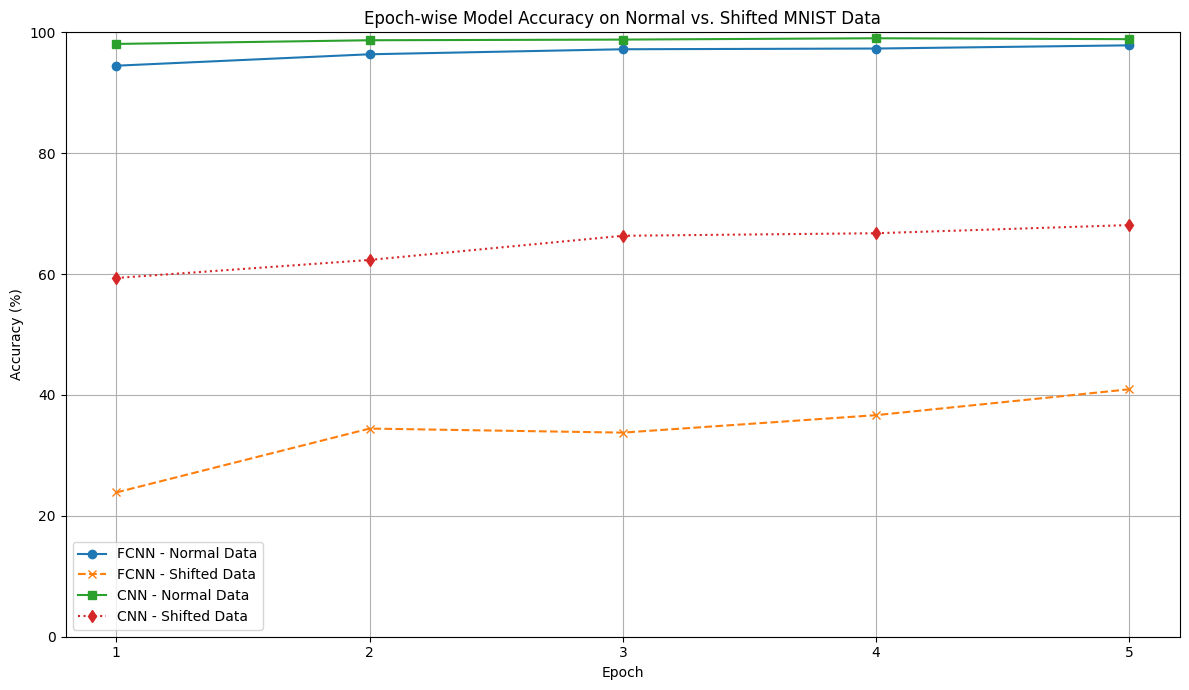

In [11]:
epochs_range = range(1, epochs + 1)

plt.figure(figsize=(12, 7))

# Plot FCNN accuracies
plt.plot(epochs_range, [acc * 100 for acc in fcnn_accuracies_normal_epochs], label='FCNN - Normal Data', marker='o')
plt.plot(epochs_range, [acc * 100 for acc in fcnn_accuracies_shifted_epochs], label='FCNN - Shifted Data', marker='x', linestyle='--')

# Plot CNN accuracies
plt.plot(epochs_range, [acc * 100 for acc in cnn_accuracies_normal_epochs], label='CNN - Normal Data', marker='s')
plt.plot(epochs_range, [acc * 100 for acc in cnn_accuracies_shifted_epochs], label='CNN - Shifted Data', marker='d', linestyle=':')

plt.title('Epoch-wise Model Accuracy on Normal vs. Shifted MNIST Data')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.xticks(epochs_range)
plt.grid(True)
plt.legend()
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# Part 3

In [12]:
def plot_filters(model, title):
    weights = model.conv1.weight.data.cpu()
    weights = (weights - weights.min())/(weights.max() - weights.min() + 1e-5)
    n = weights.shape[0]
    grid = int(np.ceil(np.sqrt(n)))
    plt.figure(figsize=(8,8))
    for i in range(n):
        plt.subplot(grid, grid, i+1)
        w = weights[i]
        if w.shape[0] == 1:
            plt.imshow(w[0], cmap='gray')
        else:
            plt.imshow(w.permute(1,2,0))
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

In [13]:
def get_activations(model, image):
    acts = {}
    def hook1(module, inp, out): acts['c1'] = out.detach().cpu()
    def hook2(module, inp, out): acts['c2'] = out.detach().cpu()
    h1 = model.conv1.register_forward_hook(hook1)
    h2 = model.conv2.register_forward_hook(hook2)
    model.eval()
    with torch.no_grad():
        model(image.unsqueeze(0).to(device))
    h1.remove(); h2.remove()
    return acts

def plot_act_maps(image, acts, title):
    c1 = acts['c1'][0].mean(0)
    c2 = acts['c2'][0].mean(0)
    fig, ax = plt.subplots(1,3, figsize=(12,4))
    if image.shape[0] == 1:
        ax[0].imshow(image.squeeze(), cmap='gray')
    else:
        ax[0].imshow(image.permute(1,2,0))
    ax[0].set_title('Original'); ax[0].axis('off')
    ax[1].imshow(c1, cmap='gray'); ax[1].set_title('Conv1'); ax[1].axis('off')
    ax[2].imshow(c2, cmap='gray'); ax[2].set_title('Conv2'); ax[2].axis('off')
    plt.suptitle(title)
    plt.show()

## MNIST filter and convolution output visualisations

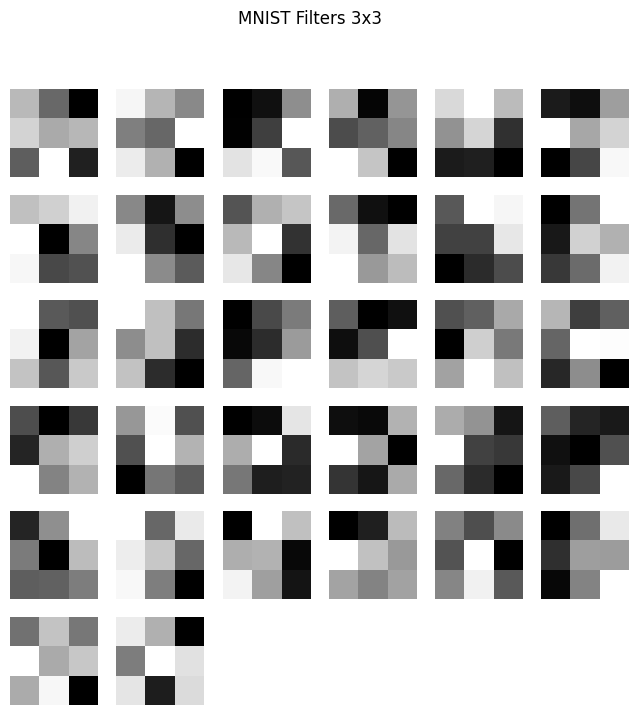

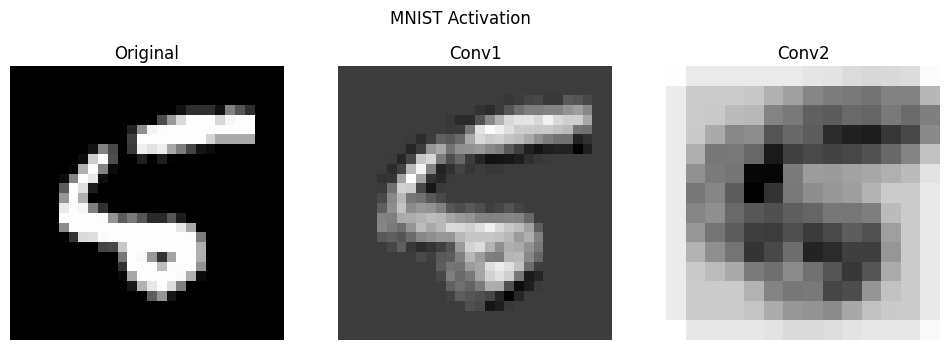

In [14]:
model_mnist = cnn_model
plot_filters(model_mnist, 'MNIST Filters 3x3')

def get_img_from_class(dataset, cls):
    for im, lab in dataset:
        if lab == cls:
            return im, lab
    raise ValueError(f'Class {cls} not found in dataset')

mnist_cls = random.randint(0,9)
mnist_img, _ = get_img_from_class(test_dataset, mnist_cls)

acts_m = get_activations(model_mnist, mnist_img)
plot_act_maps(mnist_img, acts_m, 'MNIST Activation')
